In [1]:
print("hello world")

hello world


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.src.legacy.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

2024-10-09 12:43:30.083946: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-09 12:43:30.394915: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2024-10-09 12:43:31.037218: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-10-09 12:43:31.057255: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-10-09 12:43:31.058661: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [4]:
# Mapear arquivos ocultos (.ipny) # acaba n usando pq a pasta enjoada n pode ser ignorada mais a frente
def filter_hidden_folders(folder_list):
    return [folder for folder in folder_list if not folder.startswith('.')]

In [5]:
# Caminho para os dados do dataset e o reescalador de imagens

xray_directory = 'font_results/cropped'

xray_classes = os.listdir(xray_directory)  # Filtra pastas ocultas
print(xray_classes)
print(len(xray_classes))

['g', 'V', 'W', 'r', 'i', 'a', 'G', 'I', 's', 'J', 'y', 'z', 't', 'c', 'Q', 'u', 'E', 'o', 'H', 'B', 'U', 'N', 'F', 'm', 'n', 'v', 'T', 'D', 'A', 'e', 'w', 'O', '.ipynb_checkpoints', 'S', 'K', 'l', 'C', 'q', 'p', 'Z', 'j', 'h', 'f', 'L', 'M', 'b', 'd', 'P', 'x', 'X', 'Y', 'R', 'k']
53


In [6]:
from tensorflow.keras import layers, models

# Definindo o modelo
model = Sequential()

# Definir parâmetros
input_shape = (120, 100, 1)  # Imagem 120x100, 1 canal (grayscale)
num_classes = 53  # 26 letras maiúsculas, 26 minúsculas, + 1 "null"

# Primeira camada de convolução e pooling
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
model.add(layers.MaxPooling2D((2, 2)))

# Segunda camada de convolução e pooling
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Terceira camada de convolução e pooling
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Quarta camada de convolução e pooling
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Camada de flatten
model.add(layers.Flatten())

# Camadas densas (fully connected)
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))  # Evitar overfitting

# Camada de saída
model.add(layers.Dense(num_classes, activation='softmax'))

/home/picg/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2024-10-09 12:43:31.070955: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-10-09 12:43:31.072340: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing

In [7]:
# Compilando o modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Resumo do modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 118, 98, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 59, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 57, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 8, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,311,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 53)             │        27,189 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,677 (6.02 MB)

 Trainable params: 1,578,677 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Salvar o arquivo de treinamento em diferentes epocas

# Nome/caminho do arquivo que sera salvo
filepath = "weights_cropped_original.keras" 
#filepath = "weights_normal_original.keras" 

# Define os parametros para atualizar o arquivo final
# ModelCheckpoint(nome_do_arquivo, monitor = 'parametro a ser alalisado', verbose = 1 (imprimir no console quando arquivo for salvo), save_best_only = True, mode = 'min' (objetivo minimizar perda))
checkpoint = ModelCheckpoint(filepath, monitor = 'loss', verbose = 1, save_best_only = True, mode = 'min')

# Cria uma lista que contém o ModelCheckpoint configurado usado durante o treinamento
callbacks_list = [checkpoint]

In [9]:
# Gerenciador de imagem para pre processamento
# Aumentar a base de dados 

train_datagen = ImageDataGenerator(
# Transforma os valores de pixel de (0-255 ->0.0 - 1.0 )  
    rescale=1. / 255,
# Aplica zoom aleatório às imagens dentro do intervalo especificado (0.2 -> 20%)
    zoom_range=0.2,
# Realiza uma inversão horizontal aleatória das imagens
    horizontal_flip=True,
#Este parâmetro é usado para dividir automaticamente os dados em conjuntos de treinamento e validação 
    validation_split=0.3
    )


Found 2658452 images belonging to 53 classes.


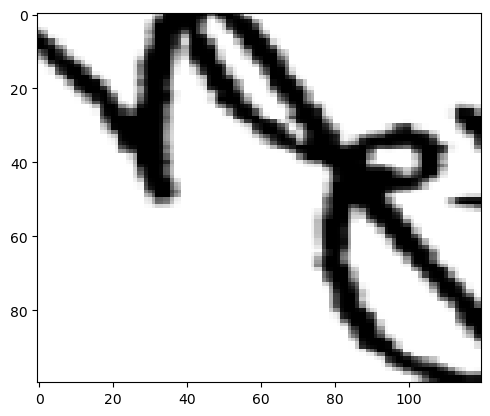

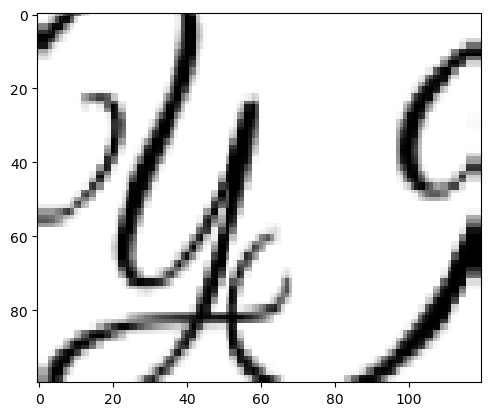

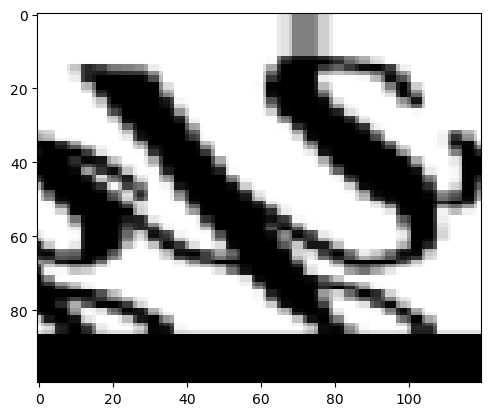

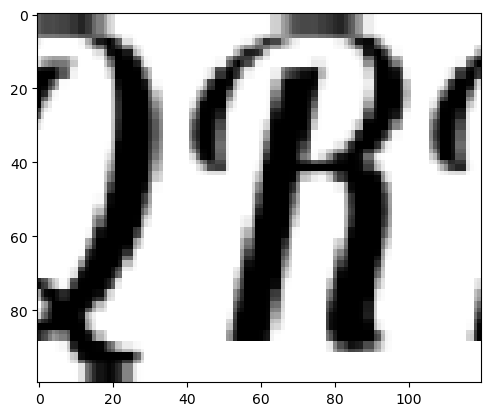

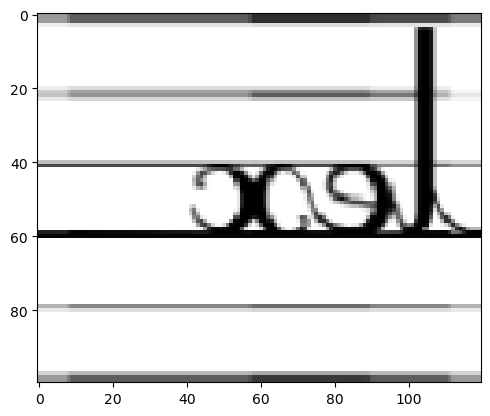

{'.ipynb_checkpoints': 0, 'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8, 'I': 9, 'J': 10, 'K': 11, 'L': 12, 'M': 13, 'N': 14, 'O': 15, 'P': 16, 'Q': 17, 'R': 18, 'S': 19, 'T': 20, 'U': 21, 'V': 22, 'W': 23, 'X': 24, 'Y': 25, 'Z': 26, 'a': 27, 'b': 28, 'c': 29, 'd': 30, 'e': 31, 'f': 32, 'g': 33, 'h': 34, 'i': 35, 'j': 36, 'k': 37, 'l': 38, 'm': 39, 'n': 40, 'o': 41, 'p': 42, 'q': 43, 'r': 44, 's': 45, 't': 46, 'u': 47, 'v': 48, 'w': 49, 'x': 50, 'y': 51, 'z': 52}
Found 1139320 images belonging to 53 classes.


In [10]:

BATCH_SIZE = 50
TARGET_SIZE=(100, 120) # é ao contrário aqui essa bussanha
CMODE='grayscale'
CLASS_MODE='categorical'
SHUFFLE = True
# Imagens para treinamento
train_generator = train_datagen.flow_from_directory(
    xray_directory,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=CMODE, 
    class_mode=CLASS_MODE,
    shuffle=SHUFFLE,
    subset='training'
)

# Obtenha um lote de imagens do generator
x_batch, y_batch = next(train_generator)

# Visualize algumas imagens geradas com suas respectivas transformações
for i in range(0, 5):  # Mostra as primeiras 5 imagens
    image = x_batch[i]
    plt.imshow(image, cmap = "gray")
    plt.show()
    
print(train_generator.class_indices)

# Imagens para validação
validation_generator = train_datagen.flow_from_directory(
        xray_directory,
        target_size=TARGET_SIZE,
        batch_size=BATCH_SIZE,
        color_mode=CMODE,
        class_mode=CLASS_MODE,
        shuffle=SHUFFLE,
        subset = 'validation'
        )

In [11]:
# Testar o gerador de dados
for data_batch, labels_batch in train_generator:
    print("Imagens: ", data_batch.shape)
    print("Labels: ", labels_batch.shape)
    break  # Apenas testar um batch


Imagens:  (50, 100, 120, 1)
Labels:  (50, 53)


# treinamento do modelo

In [12]:
history = model.fit(train_generator, epochs = 25, validation_data=validation_generator, callbacks=callbacks_list)


Epoch 1/25


/home/picg/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1728488648.414334  367035 service.cc:145] XLA service 0x7eae3800c5c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728488648.414362  367035 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2024-10-09 12:44:08.438264: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-09 12:44:08.520769: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1728

   13/53170 ━━━━━━━━━━━━━━━━━━━━ 13:13 15ms/step - accuracy: 0.0219 - loss: 3.9851 

I0000 00:00:1728488650.655795  367035 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


53164/53170 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5305 - loss: 1.7239
Epoch 1: loss improved from inf to 1.23868, saving model to weights_cropped_original.keras
53170/53170 ━━━━━━━━━━━━━━━━━━━━ 1143s 21ms/step - accuracy: 0.5305 - loss: 1.7238 - val_accuracy: 0.7718 - val_loss: 1.0086
Epoch 2/25
53163/53170 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7711 - loss: 0.8241
Epoch 2: loss improved from 1.23868 to 0.79217, saving model to weights_cropped_original.keras
53170/53170 ━━━━━━━━━━━━━━━━━━━━ 1114s 21ms/step - accuracy: 0.7711 - loss: 0.8241 - val_accuracy: 0.7955 - val_loss: 1.0007
Epoch 3/25
53169/53170 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7990 - loss: 0.7260
Epoch 3: loss improved from 0.79217 to 0.71474, saving model to weights_cropped_original.keras
53170/53170 ━━━━━━━━━━━━━━━━━━━━ 1121s 21ms/step - accuracy: 0.7990 - loss: 0.7260 - val_accuracy: 0.8102 - val_loss: 0.9241
Epoch 4/25
53167/53170 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8102 - loss

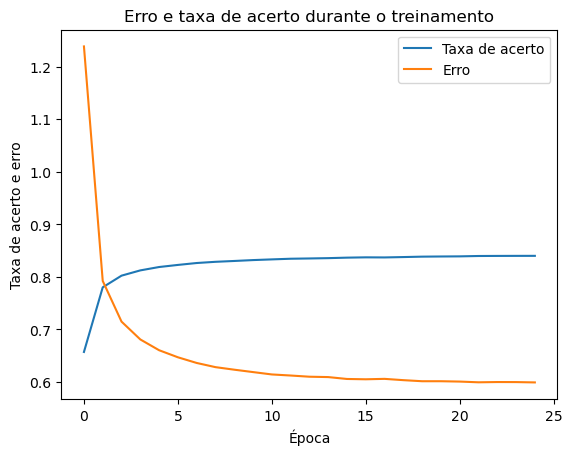

In [13]:
aux = history
history = history.history.keys() #paramestros de avaliação accuracy, loss
# Exemplo de grafico para ver taxa de acerto por taxa de erro 
plt.plot(aux.history['accuracy'])
plt.plot(aux.history['loss'])
plt.title('Erro e taxa de acerto durante o treinamento')
plt.xlabel('Época')
plt.ylabel('Taxa de acerto e erro')
plt.legend(['Taxa de acerto', 'Erro']);

In [14]:
hist_df = pd.DataFrame(aux.history)
print(hist_df)

    accuracy      loss  val_accuracy  val_loss
0   0.656984  1.238678      0.771752  1.008569
1   0.780063  0.792173      0.795518  1.000697
2   0.802249  0.714744      0.810158  0.924065
3   0.812276  0.680808      0.815458  0.951631
4   0.818694  0.660284      0.818454  0.961416
5   0.822680  0.646844      0.815463  1.009156
6   0.826312  0.636036      0.819473  1.052103
7   0.828609  0.628069      0.819171  0.954324
8   0.830212  0.623223      0.817179  0.995346
9   0.831895  0.618663      0.825888  0.968117
10  0.833216  0.614162      0.819468  1.054443
11  0.834463  0.612128      0.821039  1.058903
12  0.834989  0.609844      0.826217  1.052847
13  0.835595  0.609154      0.830486  0.990444
14  0.836536  0.605552      0.828793  0.926071
15  0.837115  0.604959      0.826164  0.933322
16  0.836942  0.605759      0.830858  1.010425
17  0.837646  0.603294      0.830055  0.998074
18  0.838432  0.601258      0.831348  0.964289
19  0.838746  0.601260      0.831825  0.939024
20  0.838982 

In [15]:
# Salvar o DataFrame em um arquivo CSV
hist_df.to_csv('training_history_cropped_original.csv', index=False)

# Carregar histórico de treinamento anterior

In [16]:
# Carregar os dados do CSV
loaded_history_df = pd.read_csv('training_history.csv')
# Exibir os dados carregados (opcional)
print(loaded_history_df)

FileNotFoundError: [Errno 2] No such file or directory: 'training_history.csv'

In [ ]:
# Plotar a perda de treinamento e validação
plt.plot(loaded_history_df['loss'], label='Loss (train)')
plt.plot(loaded_history_df['val_loss'], label='Loss (validation)')
plt.title('Loss durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

# Plotar a precisão de treinamento e validação
plt.plot(loaded_history_df['accuracy'], label='Accuracy (train)')
plt.plot(loaded_history_df['val_accuracy'], label='Accuracy (validation)')
plt.title('Precisão durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Precisão')
plt.legend()
plt.show()

In [ ]:
#Comparação de LOSS e ACCURACY entre as epocas de treino da rede

# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loaded_history_df['loss'], label='train loss')
plt.plot(loaded_history_df['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(loaded_history_df['accuracy'], label='train accuracy')
plt.plot(loaded_history_df['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


In [ ]:
#Comparação de Loss e Accuracy de redes distintas

import numpy as np

def plot_comparison(results, metric='accuracy'):
    models = list(results.keys())
    final_accuracy = [results[model][metric][-1] for model in models]
    
    plt.figure(figsize=(10, 5))
    plt.bar(models, final_accuracy)
    plt.title(f'Comparação de {metric} entre diferentes redes')
    plt.ylabel(metric.capitalize())
    plt.xlabel('Modelos')
    plt.show()


In [ ]:
#Grafico de curvas para comparação entre redes
def plot_comparison_curves(results, metric='accuracy'):
    plt.figure(figsize=(10, 5))
    
    for model, history in results.items():
        plt.plot(history[metric], label=f'{model} - train')
        plt.plot(history['val_' + metric], '--', label=f'{model} - val')
    
    plt.title(f'Comparação de {metric.capitalize()} entre Redes')
    plt.xlabel('Épocas')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.show()


In [ ]:
#Matriz Confusão
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {model_name}')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Predito')
    plt.show()



In [ ]:
#Boxplot
def plot_boxplot(results, metric='accuracy'):
    data = [history[metric] for history in results.values()]
    labels = results.keys()

    plt.figure(figsize=(10, 6))
    plt.boxplot(data, labels=labels)
    plt.title(f'Boxplot de {metric.capitalize()} entre Redes')
    plt.ylabel(metric.capitalize())
    plt.show()


In [ ]:
# defini caminho para pasta de teste
test_directory = 'dataset/test'
# lista contendo os nomes dos arquivos e diretórios presentes no caminho fornecido
os.listdir(test_directory)

In [ ]:
# Mudar a escala das imagens
test_gen = ImageDataGenerator(rescale=1./255)

test_generator = test_gen.flow_from_directory(batch_size = 13, directory = test_directory,
                                              shuffle = True, target_size = (256, 256),
                                              class_mode = 'categorical')

evaluate = model.evaluate(test_generator)

len(os.listdir(test_directory))

In [ ]:
# aplica a rede treinada em um conjunto de teste de imagens e armazena os resultados
prediction = []
original = []
image = []

# percorre as subpastas no diretório test_directory, assumindo que cada subpasta contém imagens de uma determinada classe
for i in range(len(os.listdir(test_directory))):
  # percorre os arquivos dentro de cada subpasta e processa cada imagem
  for item in os.listdir(os.path.join(test_directory, str(i))):
    
    #Etapas de processamento de img

    img = cv2.imread(os.path.join(test_directory, str(i), item))
    img = cv2.resize(img, (256, 256))
    image.append(img)
    img = img / 255
    img = img.reshape(-1, 256, 256, 3)

    #rede neural aplicada
    predict = model.predict(img)
    predict = np.argmax(predict)
    prediction.append(predict)
    original.append(i)

In [ ]:
accuracy_score(original, prediction)

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(12,12))
axes = axes.ravel()
for i in np.arange(0, 25):
  axes[i].imshow(image[i])
  axes[i].set_title('Previsão={}\nTrue={}'.format(str(labels_names[prediction[i]]), str(labels_names[original[i]])))
  axes[i].axis('off')
plt.subplots_adjust(wspace = 1.2)

In [ ]:
labels_names = {0: 'SoldasCorretas', 1: 'SoldasErradas'}

# Carrgar Keras e teste

In [17]:
from keras.models import load_model
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Carregar o modelo previamente salvo
model_load = load_model('weights_cropped_original.keras')

# Carregar a imagem e convertê-la para um array numpy em escala de cinza
image = np.array(Image.open("/home/picg/TCC/GeradorBase/font_results/cropped/x/x-txt-AlexBrush-Regular.png").convert('L'))
#image = np.array(Image.open("/home/picg/TCC/GeradorBase/white.png").convert('L'))
# Redimensionar a imagem para o tamanho esperado pela CNN (supondo 120x100)
temp_resized = cv2.resize(image, (120, 100))

print(temp_resized.shape)

# Normalizar os valores dos pixels para [0, 1]
normalized = temp_resized / 255.0

# Adicionar uma dimensão para corresponder ao formato de entrada esperado pelo modelo
final = normalized.reshape(1, 120, 100, 1)  # '1' aqui é o batch size

# Fazer a predição com o modelo carregado
prediction = model_load.predict(final)

# Exibir o resultado da predição
print("Predição:", prediction)


(100, 120)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
Predição: [[9.3233948e-22 1.5397045e-12 2.0379970e-11 6.5090178e-10 1.1559858e-21
  1.2931217e-07 6.7766103e-07 2.4955856e-05 3.3065214e-10 7.6209430e-09
  1.2860422e-08 8.4070599e-08 7.0496029e-13 0.0000000e+00 2.7148419e-18
  1.4651188e-16 3.3638339e-11 2.6664493e-10 1.8911934e-09 1.3448846e-08
  3.8611247e-06 2.2576459e-20 6.9247368e-12 1.3091441e-21 2.5052280e-13
  8.4124322e-12 4.8439864e-07 5.2651172e-09 2.3447713e-04 9.9004649e-07
  6.3969121e-12 1.0601627e-03 5.9676477e-06 2.0650967e-05 8.2755840e-08
  3.0451667e-04 1.5607342e-03 3.3964217e-01 3.3489997e-08 5.2283590e-13
  8.2652631e-09 1.6135100e-05 1.8951445e-08 2.8737352e-07 5.8246561e-04
  1.4948002e-04 8.4038254e-07 1.1903711e-07 3.1818640e-03 2.3885905e-06
  5.1554187e-05 1.0098869e-03 6.5214491e-01]]


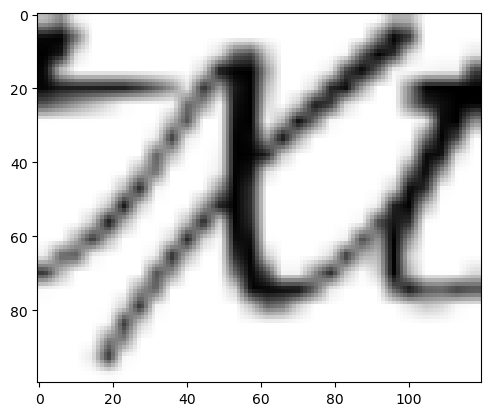

In [18]:
plt.imshow(temp_resized, cmap="gray")

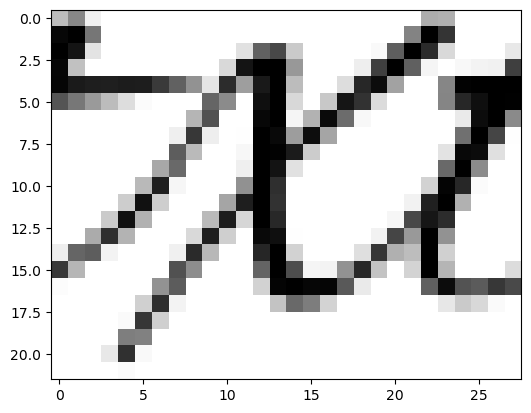

In [19]:
#image = np.array(Image.open("/home/picg/TCC/GeradorBase/font_results/normal/a/a-mam-GrandHotel-Regular.png"))
plt.imshow(image, cmap="gray")

In [20]:
import numpy as np

# Achar a classe com maior probabilidade
predicted_class = np.argmax(prediction)
'''
{'.ipynb_checkpoints': 0, 'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8, 'I': 9, 'J': 10, 'K': 11, 'L': 12, 'M': 13, 'N': 14, 'O': 15, 'P': 16, 'Q': 17, 'R': 18, 'S': 19, 'T': 20, 'U': 21, 'V': 22, 'W': 23, 'X': 24, 'Y': 25, 'Z': 26, 'a': 27, 'b': 28, 'c': 29, 'd': 30, 'e': 31, 'f': 32, 'g': 33, 'h': 34, 'i': 35, 'j': 36, 'k': 37, 'l': 38, 'm': 39, 'n': 40, 'o': 41, 'p': 42, 'q': 43, 'r': 44, 's': 45, 't': 46, 'u': 47, 'v': 48, 'w': 49, 'x': 50, 'y': 51, 'z': 52}
'''

# Definir labels (saidas) 
labels_names1 = {0: '.ipynb_checkpoints', 
                1: 'a',
                2: 'A',
                3: 'b',
                4: 'B',
                5: 'c',
                6: 'C',
                7: 'd',
                8: 'D',
                9: 'e',
                10: 'E', 
                11: 'f',
                12: 'F',
                13: 'g',
                14: 'G',
                15: 'h',
                16: 'H',
                17: 'i',
                18: 'I',
                19: 'j',
                20: 'J', 
                21: 'k',
                22: 'K',
                23: 'l',
                24: 'L',
                25: 'm',
                26: 'M',
                27: 'n',
                28: 'N',
                29: 'o',
                30: 'O', 
                31: 'p',
                32: 'P',
                33: 'q',
                34: 'Q',
                35: 'r',
                36: 'R',
                37: 's',
                38: 'S',
                39: 't',
                40: 'T', 
                41: 'u',
                42: 'U',
                43: 'v',
                44: 'V',
                45: 'w',
                46: 'W',
                47: 'x',
                48: 'X',
                49: 'y',
                50: 'Y', 
                51: 'z',
                52: 'Z',
                }
labels_names = {
    0: "g",
    1: "V",
    2: "W",
    3: "r",
    4: "i",
    5: "a",
    6: "G",
    7: "I",
    8: "s",
    9: "J",
    10: "y",
    11: "z",
    12: "t",
    13: "c",
    14: "Q",
    15: "u",
    16: "E",
    17: "o",
    18: "H",
    19: "B",
    20: "U",
    21: "N",
    22: "F",
    23: "m",
    24: "n",
    25: "v",
    26: "T",
    27: "D",
    28: "A",
    29: "e",
    30: "w",
    31: "O",
    32: ".ipynb_checkpoints",
    33: "S",
    34: "K",
    35: "l",
    36: "C",
    37: "q",
    38: "p",
    39: "Z",
    40: "j",
    41: "h",
    42: "f",
    43: "L",
    44: "M",
    45: "b",
    46: "d",
    47: "P",
    48: "x",
    49: "X",
    50: "Y",
    51: "R",
    52: "k"
}
print(f"A classe prevista é - {predicted_class}: {labels_names[predicted_class]}")


A classe prevista é - 52: k


In [ ]:
model_load.summary()